In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015 (1).csv")

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [15]:
# Missing values
df.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,1
Stroke,1
HeartDiseaseorAttack,1
PhysActivity,1
Fruits,1


In [16]:
df.fillna(df.median(), inplace=True)

In [17]:
# duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [18]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

In [19]:
selected_features = df[['GenHlth', 'HighBP', 'BMI', 'DiffWalk', 'HighChol', 'Age', 'HeartDiseaseorAttack', 'PhysHlth', 'MentHlth', 'Income']]
selected_features.head()

,GenHlth,HighBP,BMI,DiffWalk,HighChol,Age,HeartDiseaseorAttack,PhysHlth,MentHlth,Income
0,5.0,1.0,40.0,1.0,1.0,9.0,0.0,15.0,18.0,3.0
1,3.0,0.0,25.0,0.0,0.0,7.0,0.0,0.0,0.0,1.0
2,5.0,1.0,28.0,1.0,1.0,9.0,0.0,30.0,30.0,8.0
3,2.0,1.0,27.0,0.0,0.0,11.0,0.0,0.0,0.0,6.0
4,2.0,1.0,24.0,0.0,1.0,11.0,0.0,0.0,3.0,4.0


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import shap
import matplotlib.pyplot as plt


# Train/Test Split
X = selected_features

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
class_weight="balanced"
# Train Model

dtc = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

dtc.fit(X_train, y_train)

print("Decision Tree trained successfully!")

# Evaluation
y_pred = dtc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Decision Tree trained successfully!

Accuracy: 0.7001

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.70      0.80     23898
         1.0       0.29      0.72      0.42      4148

    accuracy                           0.70     28046
   macro avg       0.61      0.71      0.61     28046
weighted avg       0.84      0.70      0.74     28046



In [22]:
# SHAP
explainer = shap.Explainer(dtc, X_train)
shap_values = explainer(X_test)

shap_values_class1 = shap_values[:, :, 1]


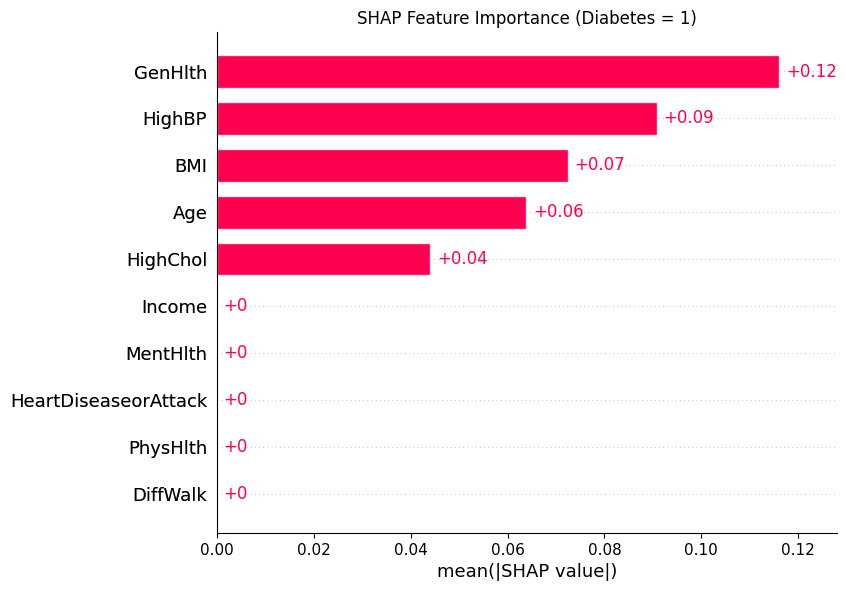

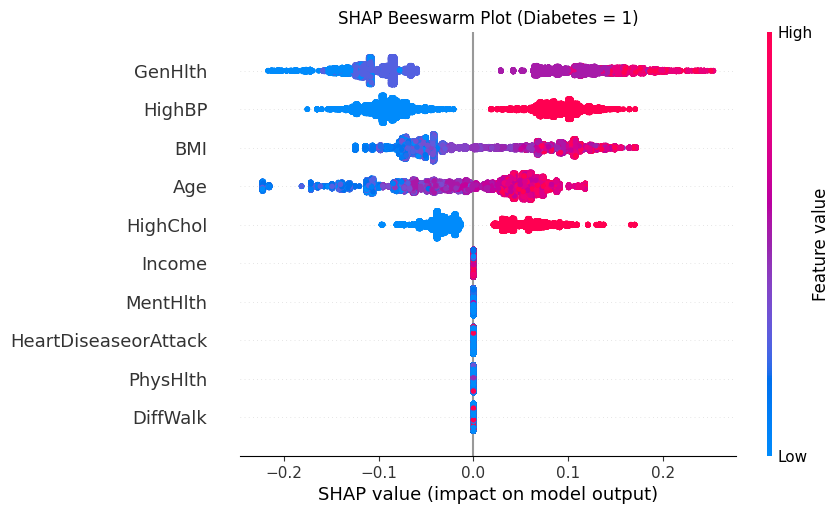

In [23]:
# Plots
import matplotlib.pyplot as plt

# Bar plot
plt.figure(figsize=(12,6))
shap.plots.bar(shap_values_class1, show=False)
plt.title("SHAP Feature Importance (Diabetes = 1)")
plt.show()

# Beeswarm plot
plt.figure(figsize=(12,6))
shap.plots.beeswarm(shap_values_class1, show=False)
plt.title("SHAP Beeswarm Plot (Diabetes = 1)")
plt.show()